### 🚀 MLOps Roadmap: XAI Pipeline Integration Strategy

**Note on Current Implementation:**
The SHAP extraction process demonstrated in this notebook serves strictly as a **debugging, validation, and exploratory environment**. By unpickling the production artifact (`best_pipeline.pkl`) locally, we ensure that the visual interpretations perfectly mirror the internal logic of the deployed champion model without any data leakage.

**Next Architectural Steps (Production Integration):**
To transition this project into a fully automated Model Governance framework, the XAI generation will be migrated into the CI/CD training script (`train.py`). The upcoming integration includes:

1. **Automated SHAP Generation:** Triggering the `LinearExplainer` automatically during the evaluation phase of the winning algorithm.
2. **MLflow Artifact Tracking:** Logging the Global Summary Plot and representative Local Waterfall Plots directly into the MLflow registry to establish an immutable audit trail.
3. **Operational Alignment:** Preparing the pipeline to eventually serve local SHAP values alongside API prediction responses, empowering the Customer Retention team with real-time churn drivers.

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


Loading data...
Loading pipeline artifact...
Extracting preprocessor and model...
🏆 CHAMPION MODEL ALGORITHM: LogisticRegression 🏆
Transforming data...
Calculating SHAP values...
Rendering plot...


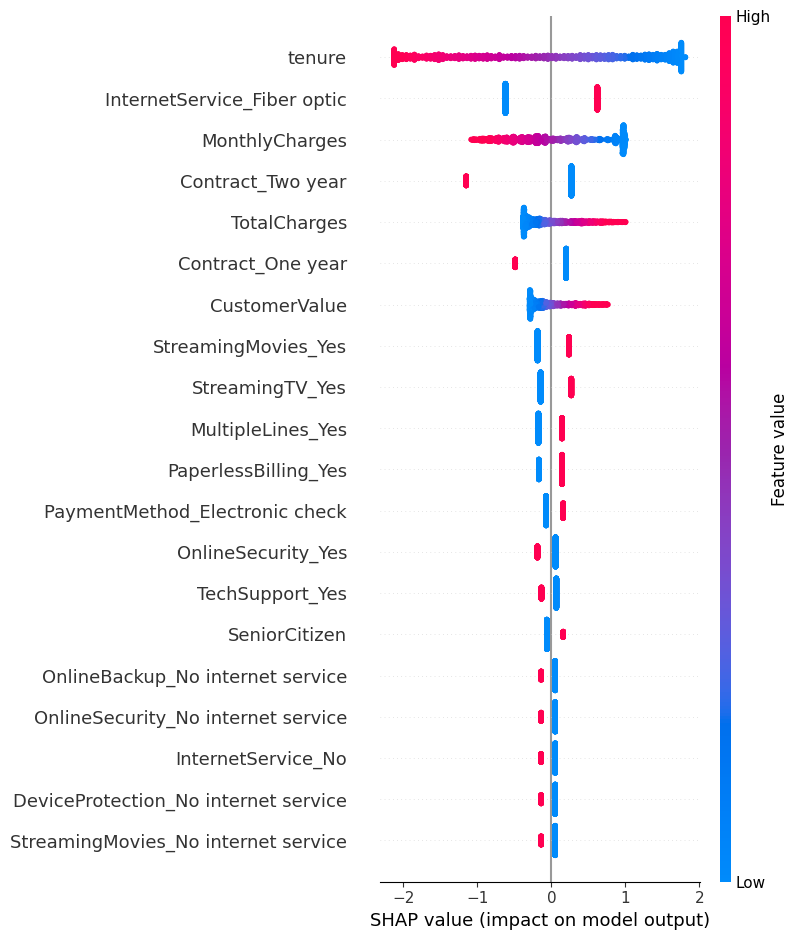

In [ ]:

import sys
import os

# Redirect path to the root repository so joblib can read custom modules
sys.path.append(os.path.abspath('..'))

import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

shap.initjs()

# 1. Load raw data and target (identical to train.py split configuration)
print("Loading data...")
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
X = df.drop(['Churn', 'customerID'], axis=1, errors='ignore') 
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Load the production pipeline artifact from disk
print("Loading pipeline artifact...")
pipeline = joblib.load('../models/best_pipeline.pkl')

# 3. Unpack pipeline & secure feature names from the custom FeatureBuilder
print("Extracting preprocessor and model...")
preprocessor = pipeline[:-1]  # All preprocessing steps
champion_model = pipeline[-1] # The final estimator (Logistic Regression)

# Secure original column names before StandardScaler turns them into anonymous arrays
X_train_features = pipeline.named_steps['features'].transform(X_train)
feature_names = X_train_features.columns

# 4. Transform training and testing data through the preprocessor pipeline
print("Transforming data...")
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Rebuild Pandas DataFrames to preserve feature names for the SHAP visualizer
X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

# 5. Execute SHAP (Linear Explainer dedicated to Logistic Regression)
print("Calculating SHAP values...")
explainer = shap.LinearExplainer(champion_model, X_train_transformed)
shap_values = explainer(X_test_transformed)

# 6. Render the final global summary plot
print("Rendering plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed)

### 📊 SHAP Summary Plot Analysis: Decoding Customer Churn Drivers

Based on the global interpretability provided by the champion model, we can extract several critical business insights:

**1. The Loyalty Anchor (`tenure`)**
* **Insight:** High tenure users (indicated by red dots) heavily push the prediction to the left (Stay), while low tenure users (indicated by blue dots) drive the prediction to the right (Churn).
* **Business Translation:** The first few months of a customer's lifecycle are the most critical. Once a user surpasses this early phase and commits to a longer tenure, their probability of churning drops significantly.

**2. The Premium Bundle Paradox (`Fiber optic` & Streaming Add-ons)**
* **Insight:** Customers subscribed to high-tier setups—specifically Fiber Optic internet, Streaming TV/Movies, and Multiple Lines (indicated by red dots on the right)—consistently show a higher probability of churning compared to base-level users.
* **Business Translation:** This reveals a critical service-to-value gap. While this cohort (likely a younger, digital-native demographic) adopts premium features, they are highly prone to leaving. There are a few key possibilities driving this behavior:
    * **Infrastructure Reliability:** Our Fiber Optic network might be experiencing stability issues, particularly concerning speed and latency.
    * **Price-to-Value Mismatch:** The premium bundle pricing does not justify the perceived quality, prompting rapid churn.
    * **Content Competitiveness:** Our streaming movie catalog may lack the appeal or volume offered by direct competitors.
    * **Promo Hunters:** This cohort may largely consist of users exploiting introductory promotions without intent for long-term loyalty.

**3. The add-on service (`contract more than one year` & support)**
* **Insight:** Customers who have more than one year contract , with support such as online security  ,tech support , online backup, online security without internet service but with device protection and streaming movie are less likely to churn
* **Business Translation:**  This suggest user who only use the telco service is less likely to churn and mostly will be senior citizen or parents who just want to keep their phone lines.

**4. The Premium Loyalty Effect (`MonthlyCharges`)**
* **Insight:** Customers with high monthly charges (indicated by red dots) heavily push the prediction to the left (Stay), while those with lower monthly charges (blue dots) drive the prediction to the right (Churn).
* **Business Translation:** Contrary to typical price-sensitivity assumptions, our high-paying subscribers demonstrate stronger loyalty. This suggests that customers willing to pay higher monthly fees are likely deeply integrated into our service ecosystem (e.g., utilizing comprehensive bundles for their households or remote work) and value stability over minor cost savings.
* **Engineering Note (Data-Driven Architecture):** The visual anomaly observed here—where high `MonthlyCharges` implies retention while high `TotalCharges` implies churn—is a mathematical artifact of multicollinearity within our Logistic Regression model. We validated this by calculating the Pearson Correlation Matrix, which revealed a severe **0.825 correlation** between `tenure` and `TotalCharges`. Because these features carry highly redundant information, the algorithm's regularization distorts the learned linear coefficients to counterbalance them, skewing the SHAP visualization. This empirical evidence dictates a strict architectural requirement: `TotalCharges` must be dropped during the automated Feature Engineering pipeline to guarantee robust, untainted interpretability in production.

**5. The Linear Scaling Anomaly (`TotalCharges` & `CustomerValue`)**
* **Insight:** Despite having different numerical ranges in the raw dataset, the SHAP value distributions for `TotalCharges` and `CustomerValue` are visually identical. High values for both features consistently drive the prediction to the right (Churn), while low values push it to the left (Stay).
* **Business Translation:** Both metrics represent the exact same customer behavior—the aggregated financial footprint of the subscriber. Analyzing them as separate entities provides zero additional business value, as they are essentially echoing the exact same narrative to the stakeholders under a different scale.
* **Engineering Note (Data-Driven Architecture):** The identical SHAP dispersion, despite differing data ranges, reveals a classic Linear Scaling anomaly. `CustomerValue` is a mathematically scaled derivative of `TotalCharges` (Correlation ≈ 1.0). In a Logistic Regression architecture, feeding the model linearly dependent features provides zero information gain while needlessly increasing dimensionality. Furthermore, tying back to our multicollinearity findings in Point 4, since `TotalCharges` overlaps heavily with `tenure`, `CustomerValue` inherits this exact same fatal flaw. To optimize the production pipeline and maintain strict model interpretability, **both** `TotalCharges` and `CustomerValue` must be aggressively pruned during the automated feature selection phase.

Generating Kaggle-style Dependence Plot for 'MonthlyCharges'...


<Figure size 1000x600 with 0 Axes>

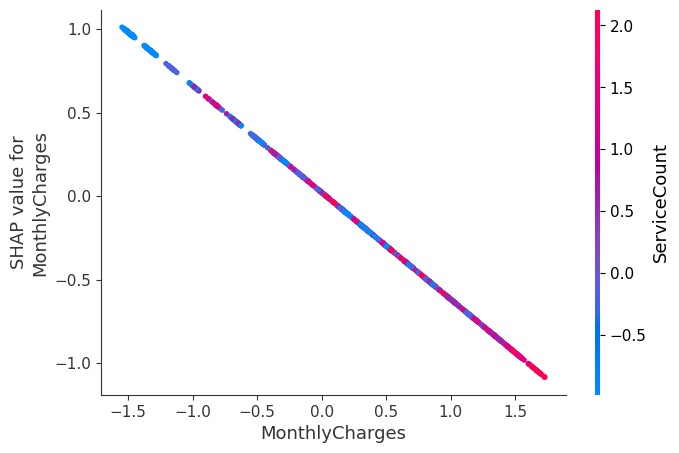

In [15]:
import shap
import matplotlib.pyplot as plt

# Define the target feature you want to inspect 
# (Make sure the feature name matches your X_test_transformed columns)
feature_name = 'MonthlyCharges' 

print(f"Generating Kaggle-style Dependence Plot for '{feature_name}'...")
plt.figure(figsize=(10, 6))

# Render the dependence plot
shap.dependence_plot(
    feature_name,
    shap_values.values,
    X_test_transformed,
    interaction_index="auto", # Automatically detects and colors by the strongest interacting feature
    show=True
)

Generating Waterfall Plot for Customer Index 0...


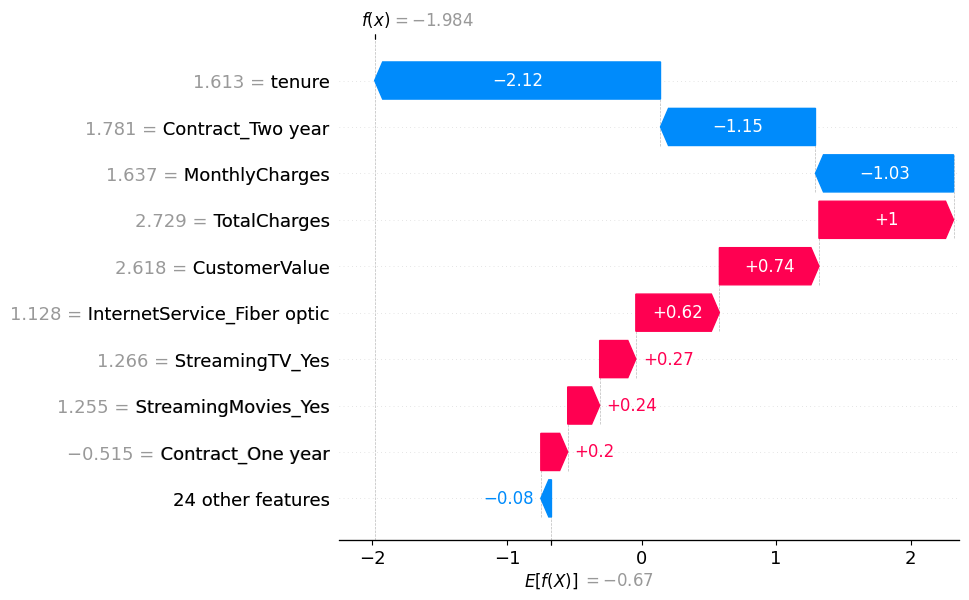

Actual Churn Status for this customer: 0


In [11]:
# =====================================================================
# 7. LOCAL INTERPRETABILITY: WATERFALL PLOT FOR A SINGLE CUSTOMER
# Production Use Case: Explaining an individual prediction to Customer Service
# =====================================================================

import shap
import matplotlib.pyplot as plt

# Select a specific customer index from the test set (e.g., index 0)
target_customer_index = 0

print(f"Generating Waterfall Plot for Customer Index {target_customer_index}...")
plt.figure(figsize=(10, 6))

# If shap_values is a modern SHAP Explanation object, we can slice it directly.
# If it's a raw numpy array (depending on SHAP version), we handle it accordingly.
try:
    # Modern SHAP Explanation slicing
    single_shap_value = shap_values[target_customer_index]
    
    shap.plots.waterfall(single_shap_value, show=True)
    
except Exception as e:
    print(f"Notice: Falling back to force_plot style or bar representation due to: {e}")
    # Fallback for older numpy matrix structures in LinearExplainer
    shap.plots.force(
        explainer.expected_value, 
        shap_values[target_customer_index], 
        X_test_transformed.iloc[target_customer_index],
        matplotlib=True
    )

print(f"Actual Churn Status for this customer: {y_test.iloc[target_customer_index]}")

Loading data for Multicollinearity check...

--- 1. Pearson Correlation Matrix ---


,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


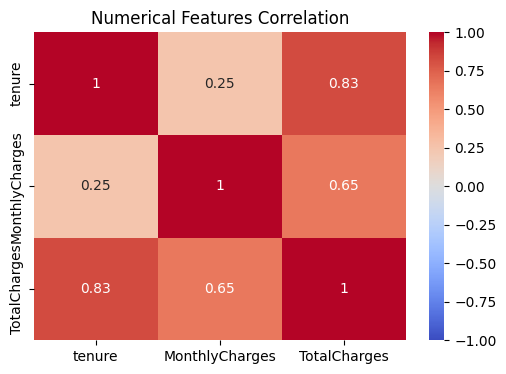


--- 2. Variance Inflation Factor (VIF) ---


,Feature,VIF_Score
1,tenure,5.844646
2,MonthlyCharges,3.225293
3,TotalCharges,9.526697


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Load data and select only the numerical features
print("Loading data for Multicollinearity check...")
df_mc = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Handle TotalCharges format (it is originally stored as string/object with blank spaces)
df_mc['TotalCharges'] = pd.to_numeric(df_mc['TotalCharges'], errors='coerce')
df_mc = df_mc.dropna(subset=['TotalCharges'])

# 3. Isolate the suspected collinear features
num_features = df_mc[['tenure', 'MonthlyCharges', 'TotalCharges']]

# ==========================================
# METHOD 1: PEARSON CORRELATION MATRIX
# ==========================================
print("\n--- 1. Pearson Correlation Matrix ---")
corr_matrix = num_features.corr()
display(corr_matrix)

# Render heatmap for visual proof
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numerical Features Correlation')
plt.show()

# ==========================================
# METHOD 2: VARIANCE INFLATION FACTOR (VIF)
# ==========================================
print("\n--- 2. Variance Inflation Factor (VIF) ---")
# VIF requires a constant/intercept column to be perfectly accurate
num_features_with_const = num_features.copy()
num_features_with_const.insert(0, 'const', 1)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = num_features_with_const.columns
vif_data["VIF_Score"] = [
    variance_inflation_factor(num_features_with_const.values, i) 
    for i in range(num_features_with_const.shape[1])
]

# Display the results (excluding the constant)
display(vif_data[vif_data["Feature"] != 'const'])